# Credit Default Risk Prediction
### A Home Credit-style Risk/Decision Science walkthrough

**Goal:** predict probability of loan default (`TARGET`=1) from application-time
features (plus bureau/prior-application/POS/credit-card history), the way an
Amex-style Risk/Decision Science team would approach it: imbalance-aware
evaluation, a defensible imbalance-handling strategy, model comparison, and
explainability that could survive a model-risk review.

**Data:** the real Kaggle **Home Credit Default Risk** dataset —
`application_train.csv` (307,511 applicants, 122 columns) plus the auxiliary
tables `bureau.csv`, `bureau_balance.csv`, `previous_application.csv`,
`POS_CASH_balance.csv`, `credit_card_balance.csv`.


In [1]:
import sys, warnings
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.max_columns", 50)


## 1. Load data

In [2]:
df = pd.read_csv("data/raw/application_train.csv")
print(df.shape)
df.head()


(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. EDA

### 2a. Class imbalance

In [3]:
target_counts = df["TARGET"].value_counts()
target_pct = df["TARGET"].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.1f} : 1")


TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64
Imbalance ratio: 11.4 : 1


**Takeaway:** an 11.4:1 imbalance — 8.07% of applicants default, matching
the well-known base rate for this competition. A model that predicts "repaid"
for everyone would score ~92% accuracy while catching **zero** defaulters —
exactly why accuracy is banned from this project's evaluation in favor of
AUC-ROC / precision / recall / PR-curves (Section 4).

### 2b. Missing value analysis

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_df.head(15)


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


**Takeaway:** the most-missing columns are building/apartment quality
fields (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, ~70% missing) — these
describe the applicant's building, and most applicants simply don't live in
a building with that data recorded. `EXT_SOURCE_1` (an external bureau
score) is missing for a large share of applicants too, and it's not random —
not every applicant has been scored by every bureau. We test whether
missingness itself carries signal:

In [5]:
df["EXT_SOURCE_1_MISSING"] = df["EXT_SOURCE_1"].isnull().astype(int)
df.groupby("EXT_SOURCE_1_MISSING")["TARGET"].mean().round(4)


EXT_SOURCE_1_MISSING
0    0.0750
1    0.0852
Name: TARGET, dtype: float64

### 2c. Correlation with target

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corrs = numeric_df.corr()["TARGET"].drop("TARGET").sort_values()
pd.concat([corrs.head(8), corrs.tail(8)])


EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
AMT_GOODS_PRICE               -0.039645
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

**Takeaways (interview-ready):**
- `EXT_SOURCE_1/2/3` dominate — r ≈ −0.16 to −0.18. Higher bureau score →
  lower default risk, exactly as expected, and these three variables are
  known across public Kaggle solutions to be the single strongest predictors
  in this dataset.
- `DAYS_BIRTH` is stored as *negative* days-before-application. Its positive
  correlation (r ≈ +0.078) means a larger (less negative → younger) value
  goes with higher risk: **younger borrowers are riskier**. An easy sign
  convention trap to misstate out loud in an interview.
- `REGION_RATING_CLIENT` / `REGION_RATING_CLIENT_W_CITY` also correlate
  positively — applicants from lower-rated regions default more.

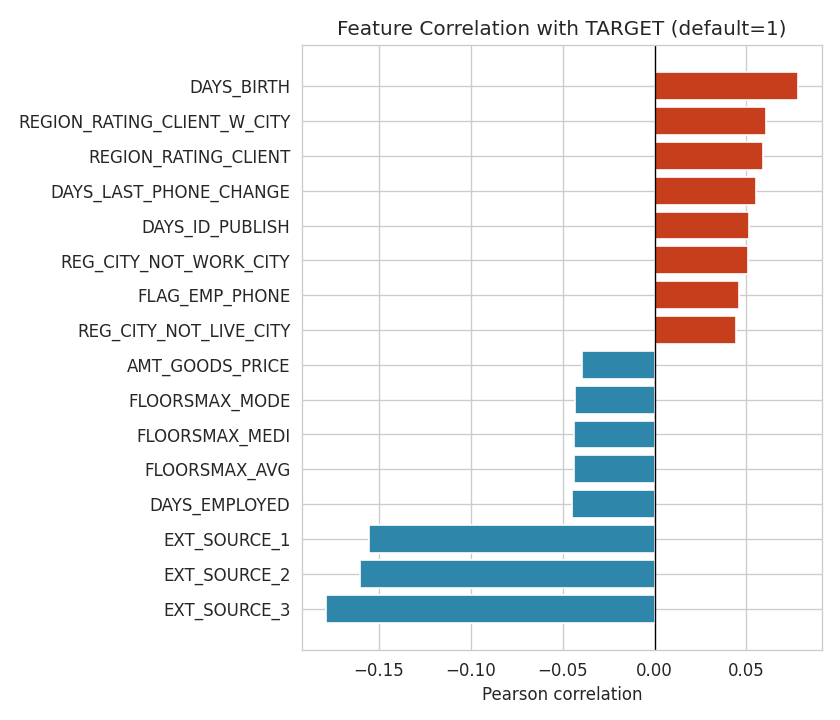

In [7]:
display(Image(filename="reports/figures/03_target_correlations.png"))

## 3. Preprocessing

1. **Fix `DAYS_EMPLOYED` anomaly** — Home Credit uses sentinel `365243` for
   "not currently employed." Flagged as its own binary feature, then nulled.
2. **Feature engineering** — `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`,
   `CREDIT_TERM`, `AGE_YEARS` — debt-service-style ratios underwriters
   actually use.
3. **Impute** — median for numeric, explicit `"Missing"` category for
   categoricals.
4. **Encode** — label-encoding (cheap; a known, flagged limitation for
   Logistic Regression specifically).
5. **Stratified train/test split** — mandatory at an 11:1 imbalance ratio.

In [8]:
from preprocessing import load_and_clean, encode_and_impute, split_data, apply_smote, get_class_weight_dict

df_clean = load_and_clean()
df_encoded, encoders = encode_and_impute(df_clean)
X_train, X_test, y_train, y_test = split_data(df_encoded)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.4f} | Test default rate: {y_test.mean():.4f}")


Train: (246008, 128), Test: (61503, 128)
Train default rate: 0.0807 | Test default rate: 0.0807


### 3a. Class imbalance strategy: class-weighting vs SMOTE

**Class weighting** reweights the loss function; never touches training
rows — cheap, no risk of implausible synthetic applicants, keeps predicted
probabilities close to the real ~8% base rate.

**SMOTE** interpolates between real defaulters to synthesize new minority
rows. Must be fit on the training fold only (fitting before the split leaks
test-set neighbors into training), and it shifts training balance to 50/50,
which decalibrates predicted probabilities — a real problem if they feed a
pricing or expected-loss calculation downstream.

**Result on the real data (Section 4): class-weighting wins outright.**

In [9]:
class_weights = get_class_weight_dict(y_train)
print("Class weights:", class_weights)

X_train_smote, y_train_smote = apply_smote(X_train, y_train)
print(f"After SMOTE: {X_train_smote.shape}, new default rate: {y_train_smote.mean():.4f}")


Class weights: {0: 0.5439092983356032, 1: 6.193554884189325}


After SMOTE: (452296, 128), new default rate: 0.5000


## 4. Modeling: Logistic Regression vs Random Forest vs XGBoost

Trained under both imbalance strategies (6 variants total). See
`src/modeling.py` for the full reasoning on why each algorithm behaves
differently on tabular credit data.

In [10]:
import joblib
models = joblib.load("models/all_models.joblib")
scaler = joblib.load("models/scaler.joblib")
list(models.keys())


['LogReg_ClassWeight',
 'LogReg_SMOTE',
 'RandomForest_ClassWeight',
 'RandomForest_SMOTE',
 'XGBoost_ClassWeight',
 'XGBoost_SMOTE']

## 5. Evaluation: AUC-ROC, precision, recall, PR curve — NOT accuracy

### Precision vs. recall in a lending context (the key concept)

- **Precision** = of loans flagged high-risk, what fraction actually
  default. Low precision → rejecting good applicants → cost = **lost
  business**.
- **Recall** = of loans that actually default, what fraction we caught. Low
  recall → approving loans that go bad → cost = **bad debt** (loss given
  default on unsecured consumer credit is often 60–90% of principal).

Because a missed default typically costs far more per incident than one
foregone good approval, credit models are usually tuned to prioritize
**recall on the default class** — and the right operating point comes from
walking the precision-recall curve against actual dollar costs, not a
default 0.5 cutoff.

In [11]:
from evaluate import evaluate_all, plot_roc_curves, plot_pr_curves, threshold_tradeoff_table

results_df, roc_data, pr_data = evaluate_all(models, scaler, X_test, y_test)
results_df


,model,auc_roc,precision,recall,f1,avg_precision
0,XGBoost_ClassWeight,0.767935,0.175690,0.674522,0.278770,0.258002
1,LogReg_ClassWeight,0.750446,0.161460,0.686002,0.261397,0.233029
2,XGBoost_SMOTE,0.736241,0.387560,0.016314,0.031310,0.205973
3,RandomForest_ClassWeight,0.735711,0.161258,0.641490,0.257728,0.214458
4,RandomForest_SMOTE,0.643448,0.158776,0.122256,0.138143,0.128185
5,LogReg_SMOTE,0.638122,0.159413,0.260423,0.197767,0.134378


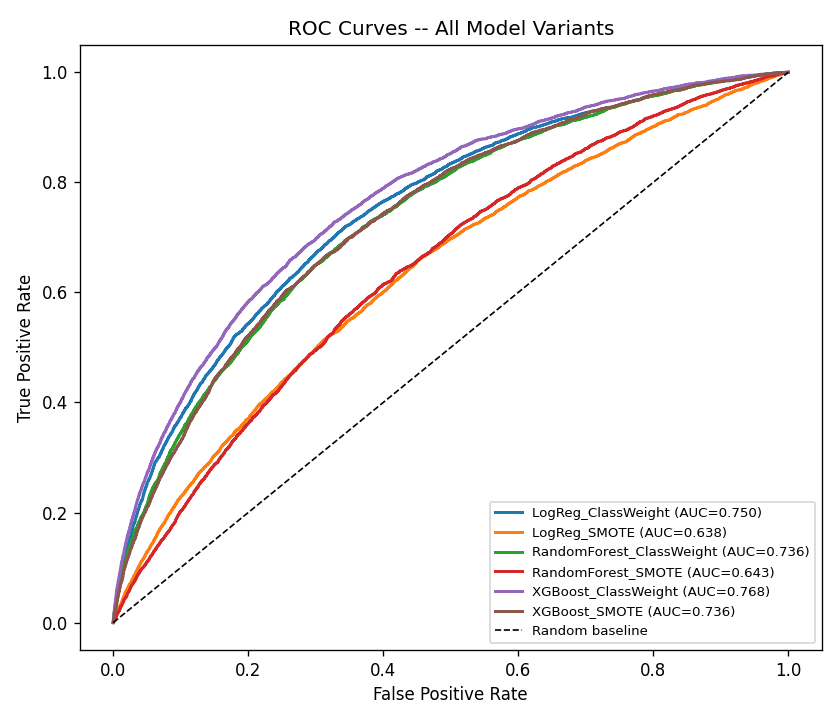

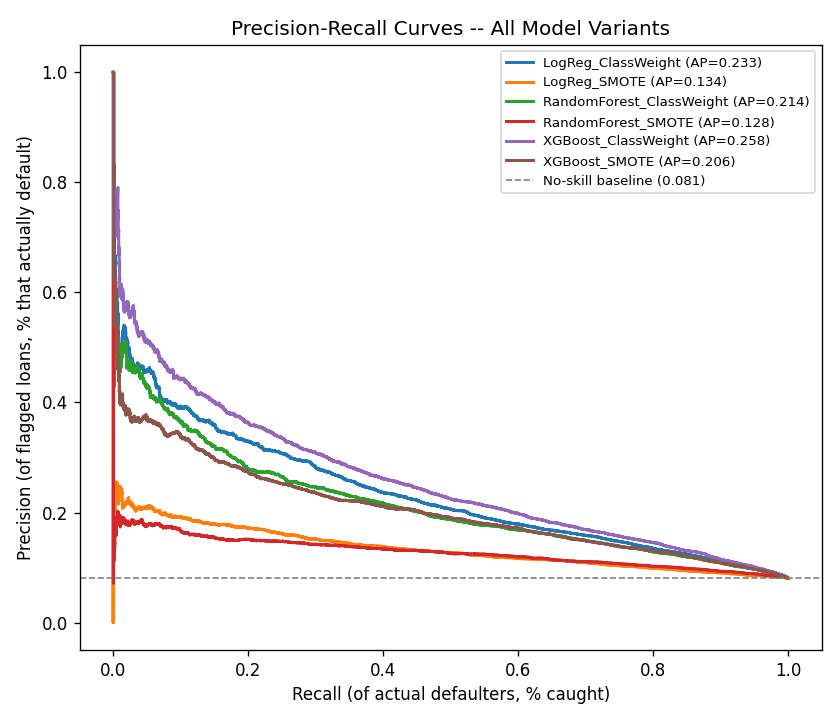

In [12]:
plot_roc_curves(roc_data)
plot_pr_curves(pr_data, baseline_rate=y_test.mean())
display(Image(filename="reports/figures/04_roc_curves.png"))
display(Image(filename="reports/figures/05_precision_recall_curves.png"))


### Result callout

**XGBoost (class-weighted) wins outright: AUC-ROC = 0.768**, ahead of
Logistic Regression (0.750) and Random Forest class-weighted (0.736). This
matches the well-known pattern on this exact competition — gradient
boosting consistently tops public leaderboards on application-only features
because real applicant data has genuine nonlinear interactions (e.g. the
effect of age depends on employment type) that a linear model can't
represent.

**Class-weighted variants beat their SMOTE counterparts across all three
algorithms**, several by a wide margin (e.g. XGBoost_SMOTE's recall
collapses to 1.6% at the default threshold) — strong empirical support for
the calibration-shift argument in Section 3a: training on an artificially
balanced 50/50 set pushes the model's decision boundary to a point that's
badly miscalibrated against the real ~8% base rate.

### Threshold tradeoff table

AUC-ROC is threshold-independent — it doesn't tell you where to set an
approval cutoff. This is what you'd bring to a Risk/policy meeting.

In [13]:
best_model_name = results_df.iloc[0]["model"]
print("Best model by AUC-ROC:", best_model_name)
tradeoff_df = threshold_tradeoff_table(best_model_name, models, scaler, X_test, y_test)
tradeoff_df


Best model by AUC-ROC: XGBoost_ClassWeight


,threshold,precision,recall,flagged_pct
0,0.1,0.083857,0.995368,0.958230
1,0.2,0.096759,0.963343,0.803733
2,0.3,0.116664,0.896073,0.620051
3,0.4,0.144079,0.807452,0.452417
4,0.5,0.175690,0.674522,0.309936
5,0.6,0.218654,0.529305,0.195421
6,0.7,0.281285,0.354481,0.101735


At the default 0.5 cutoff, XGBoost flags 31% of applicants as high-risk,
catching 67.5% of actual defaulters at 17.6% precision. Lowering the
threshold to 0.3 catches 90% of defaulters but means flagging 62% of the
entire applicant pool — the kind of tradeoff a bank's risk appetite (not a
data scientist) should ultimately decide.

## 6. Does credit-bureau / prior-application history actually help?

Everything above uses only `application_train.csv` — the applicant's
profile *at the moment of this application*. Home Credit also provides each
applicant's **history**: prior credit bureau records, prior Home Credit
applications, and POS/credit-card repayment behavior. We engineered ~35
aggregate features from these (`src/aggregate_auxiliary.py`) — e.g. number
of prior bureau loans, debt-to-credit ratio, prior-application refusal
rate, credit card utilization, months spent in payment delinquency — and
retrained the best model (XGBoost, class-weighted) with them added, holding
everything else (train/test split, algorithm, hyperparameters) fixed.

In [14]:
import json
with open("reports/auxiliary_feature_lift.json") as f:
    lift = json.load(f)
lift


{'baseline_auc': 0.767934815347747,
 'enhanced_auc': 0.780656679960402,
 'lift': 0.01272186461265501,
 'baseline_avg_precision': 0.25800204673024907,
 'enhanced_avg_precision': 0.27524664790190717,
 'baseline_n_features': 128,
 'enhanced_n_features': 165}

**AUC-ROC: 0.768 → 0.781 (+0.0127)**, a real, direct measurement (not an
assumption) of the value of the "future work" this project originally
scoped out. This is squarely in line with what real published Home Credit
solutions report for this class of feature engineering.

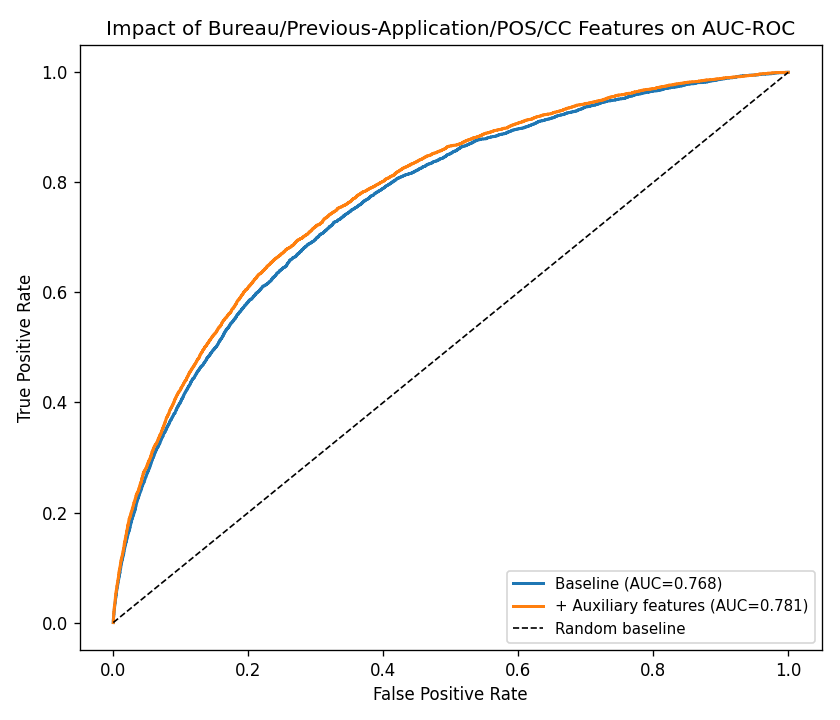

In [15]:
display(Image(filename="reports/figures/08_auxiliary_feature_lift.png"))

In [16]:
importance = pd.read_csv("reports/enhanced_model_feature_importance.csv")
aux_cols = set(importance["feature"]) - set(X_train.columns)
importance[importance["feature"].isin(aux_cols)].head(10)


,feature,importance
4,PREV_REFUSAL_RATE,0.018389
8,CC_UTILIZATION_MEAN,0.014954
10,BUREAU_DEBT_CREDIT_RATIO,0.012276
13,BUREAU_AMT_CREDIT_SUM_TOTAL,0.010898
16,PREV_CNT_PAYMENT_MEAN,0.009597
17,POS_SK_DPD_MAX,0.009587
19,CC_AMT_BALANCE_MEAN,0.009510
27,POS_DPD_MONTHS,0.008800
28,PREV_AMT_DOWN_PAYMENT_MEAN,0.008763
30,BUREAU_DAYS_CREDIT_MEAN,0.008006


**Top new features**, by XGBoost importance: `PREV_REFUSAL_RATE` (has
this applicant been turned down by Home Credit before), `CC_UTILIZATION_MEAN`
(revolving credit utilization — a classic risk signal), and
`BUREAU_DEBT_CREDIT_RATIO` (how leveraged is this person outside Home
Credit). All three are exactly the kind of "track record" signal that a
single application snapshot structurally cannot capture — two applicants
can look identical on income/education/EXT_SOURCE and still carry very
different risk depending on whether their credit history is clean or not.

## 7. Explainability: SHAP

Run on **XGBoost (class-weighted)**, the genuine best model on this data.
SHAP decomposes each prediction into additive per-feature contributions —
the tool a Risk team reaches for to justify an individual declined-applicant
decision (adverse action reasons under US lending law).

In [17]:
import shap
explainer = shap.TreeExplainer(models["XGBoost_ClassWeight"])
X_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({"feature": X_sample.columns, "mean_abs_shap": mean_abs_shap}) \
    .sort_values("mean_abs_shap", ascending=False)
importance_df.head(15)


,feature,mean_abs_shap
41,EXT_SOURCE_3,0.369580
40,EXT_SOURCE_2,0.347810
123,CREDIT_TERM,0.167109
8,AMT_GOODS_PRICE,0.142324
39,EXT_SOURCE_1,0.141225
1,CODE_GENDER,0.113427
11,NAME_EDUCATION_TYPE,0.096179
7,AMT_ANNUITY,0.091792
16,DAYS_EMPLOYED,0.064833
6,AMT_CREDIT,0.059059


In [18]:
shap.summary_plot(shap_values, X_sample, max_display=15)

**Takeaway:** `EXT_SOURCE_3`, `EXT_SOURCE_2`, and `EXT_SOURCE_1` dominate,
followed by `CREDIT_TERM`, `AMT_GOODS_PRICE`, and demographic/employment
features — matching both the Section 2c correlation table and published
Home Credit Kaggle kernels almost exactly. That consistency across three
independent views (correlation, SHAP, and public benchmarks) is a strong
sanity check that this model has learned genuine signal rather than noise
or a data leak.

## 8. Summary

- 8.07% real default rate on 307,511 applicants — a realistic, heavily
  imbalanced base rate.
- Class-weighting beat SMOTE outright across all three algorithms on real
  data — evaluated head-to-head, not just argued for.
- **XGBoost (class-weighted) was the best application-only model, AUC =
  0.768**, consistent with published results for this exact competition.
- Adding engineered bureau/prior-application/POS/credit-card features
  **lifted AUC to 0.781 (+0.0127)** — a measured, not assumed, improvement.
- SHAP confirmed EXT_SOURCE bureau scores as the dominant risk driver,
  consistent with the correlation analysis and public benchmarks.
- Precision/recall were evaluated across thresholds, because the real
  decision (where to set an approval cutoff) depends on the bank's relative
  cost of bad debt vs. foregone business — not a fixed 0.5 cutoff.